In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [78]:
agency = pd.read_csv('/content/agency (1).txt')
calendar = pd.read_csv('/content/calendar (1).txt')
routes = pd.read_csv('/content/routes (1).txt')
stop_times = pd.read_csv('/content/stop_times (1).txt')
stops = pd.read_csv('/content/stops (1).txt')
trips = pd.read_csv('/content/trips (1).txt')
shapes = pd.read_csv('/content/shapes (1).txt')

In [79]:
agency_name = agency.loc[0, 'agency_name']
start_date = calendar['start_date'].min()
end_date = calendar['end_date'].max()
print("Agency Name:", agency_name)
print("Start Date:", start_date)
print("End Date:", end_date)

Agency Name: Delhi Metro Rail Corporation
Start Date: 20190101
End Date: 20251231


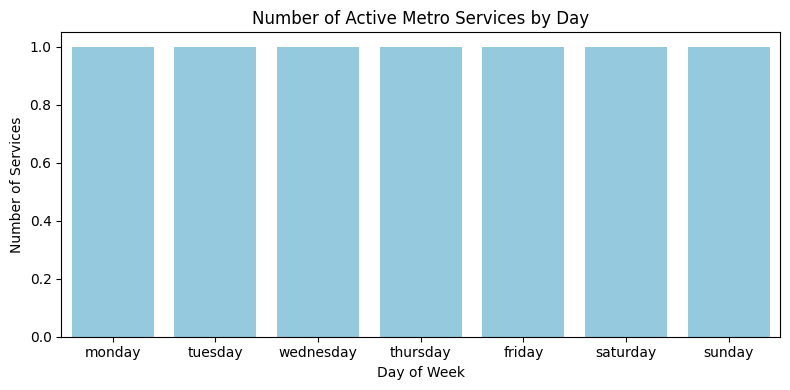

In [80]:
days = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
service_freq = calendar[days].sum()
plt.figure(figsize=(8, 4))
sns.barplot(x=service_freq.index, y=service_freq.values, color='skyblue')

plt.title('Number of Active Metro Services by Day')
plt.ylabel('Number of Services')
plt.xlabel('Day of Week')
plt.tight_layout()
plt.show()

In [81]:
merged = stop_times.merge(trips, on='trip_id').merge(routes, on='route_id').merge(stops, on='stop_id')

In [82]:
stop_times.head()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,continuous_pickup,continuous_drop_off
0,0,05:28:08,05:28:28,21,0,NaN,0,0,0.000,1,NaN,NaN
1,0,05:30:58,05:31:18,20,1,NaN,0,0,1202.405,1,NaN,NaN
2,0,05:33:28,05:33:48,19,2,NaN,0,0,2480.750,1,NaN,NaN
3,0,05:35:33,05:35:53,18,3,NaN,0,0,3314.936,1,NaN,NaN
4,0,05:37:53,05:38:13,17,4,NaN,0,0,4300.216,1,NaN,NaN


In [83]:
routes.head()

,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type,route_url,route_color,route_text_color,route_sort_order,continuous_pickup,continuous_drop_off
0,33,NaN,R_SP_R,RAPID_Phase 3 (Rapid Metro) to Sector 55-56 (R...,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
1,31,NaN,G_DD_R,GRAY_Dhansa Bus Stand to Dwarka,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
2,29,NaN,P_MS_R,PINK_Shiv Vihar to Majlis Park,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
3,12,NaN,M_JB,MAGENTA_Janak Puri West to Botanical Garden,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
4,11,NaN,P_MS,PINK_Majlis Park to Shiv Vihar,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN


In [84]:
trips.head()

,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible,bikes_allowed
0,0,weekday,0,NaN,NaN,NaN,NaN,shp_1_30,0,0
1,0,weekday,1,NaN,NaN,NaN,NaN,shp_1_30,0,0
2,0,weekday,10,NaN,NaN,NaN,NaN,shp_1_30,0,0
3,0,weekday,100,NaN,NaN,NaN,NaN,shp_1_30,0,0
4,2,weekday,1000,NaN,NaN,NaN,NaN,shp_1_13,0,0


In [85]:
merged.head()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,...,route_color,route_text_color,route_sort_order,continuous_pickup_y,continuous_drop_off_y,stop_code,stop_name,stop_desc,stop_lat,stop_lon
0,0,05:28:08,05:28:28,21,0,NaN,0,0,0.000,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Rithala,NaN,28.720821,77.105042
1,0,05:30:58,05:31:18,20,1,NaN,0,0,1202.405,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Rohini West,NaN,28.715008,77.115746
2,0,05:33:28,05:33:48,19,2,NaN,0,0,2480.750,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Rohini East,NaN,28.707941,77.125732
3,0,05:35:33,05:35:53,18,3,NaN,0,0,3314.936,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Pitampura,NaN,28.703180,77.132355
4,0,05:37:53,05:38:13,17,4,NaN,0,0,4300.216,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Kohat Enclave,NaN,28.697943,77.140465


In [86]:
shapes.head()

,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
0,shp_1_2,28.615887,77.022461,1,0.000
1,shp_1_2,28.616341,77.022499,2,50.510
2,shp_1_2,28.617985,77.022453,3,233.586
3,shp_1_2,28.618252,77.022453,4,263.487
4,shp_1_2,28.618425,77.022438,5,282.857


In [87]:
merged['hour'] = pd.to_datetime(merged['arrival_time'], errors='coerce').dt.hour

In [88]:
# Count number of train stops at each station by hour
heat_data = merged.groupby(['stop_name', 'hour']).size().reset_index(name='stop_count')

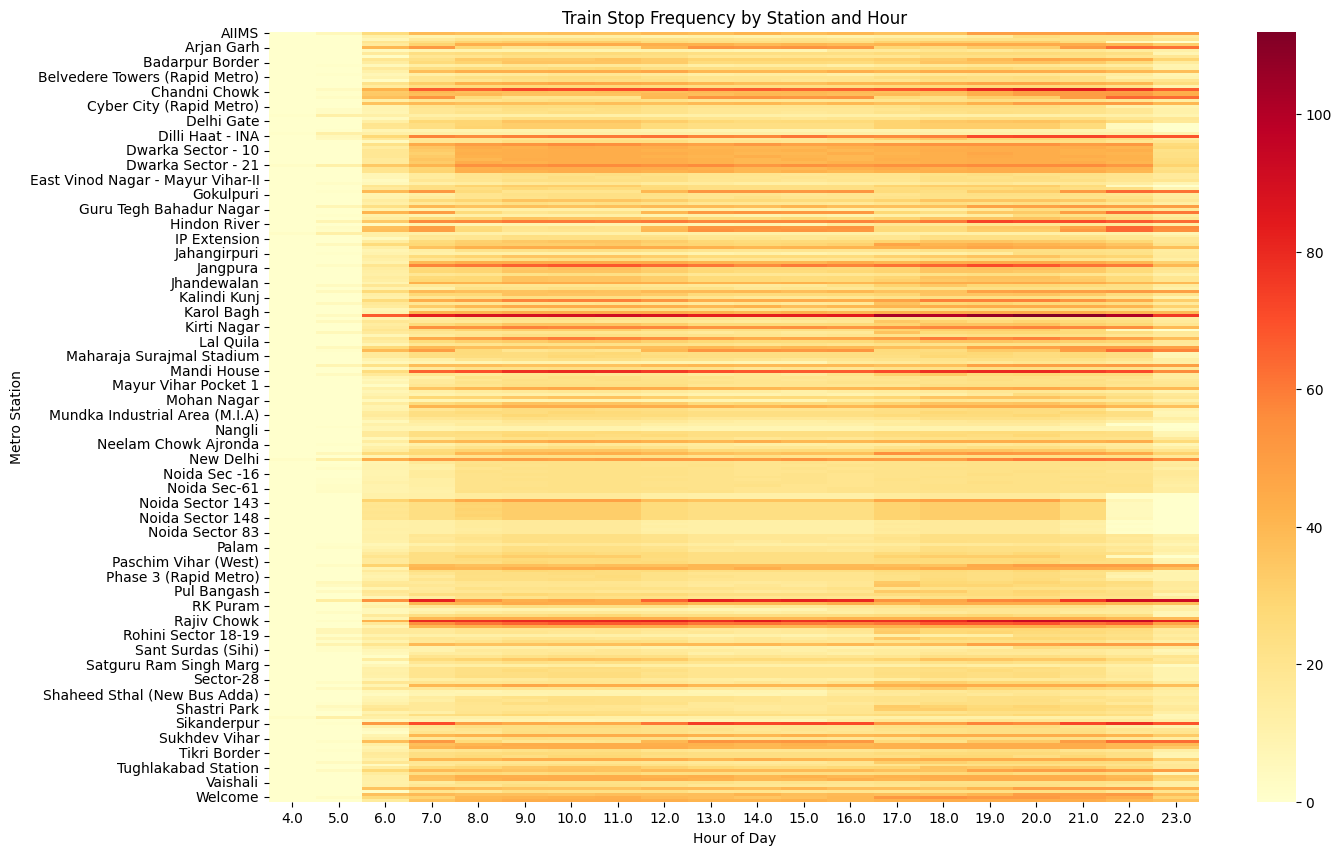

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = heat_data.pivot(index='stop_name', columns='hour', values='stop_count').fillna(0)

plt.figure(figsize=(15, 10))
sns.heatmap(pivot, cmap='YlOrRd')
plt.title("Train Stop Frequency by Station and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Metro Station")
plt.show()

In [90]:
pip install folium pandas

In [91]:
import pandas as pd
import folium
import matplotlib.pyplot as plt

# Reload the original shapes data to ensure correct columns for this cell
shapes = pd.read_csv('/content/shapes (1).txt')

#  Step 2: Match each shape with its route and route name
# 'shape_id' tells us the path taken by the metro
shape_route_info = trips[['shape_id', 'route_id']].drop_duplicates()
shape_route_info = shape_route_info.merge(
    routes[['route_id', 'route_long_name']],
    on='route_id',
    how='left'
)

# Step 3: Merge shape points with route info
shape_data = shapes.merge(shape_route_info, on='shape_id', how='left')

# Step 4: Assign a unique color to every route_id
unique_routes = shape_data['route_id'].dropna().unique()
num_routes = len(unique_routes)

# Use matplotlib's built-in colormap to generate distinct colors
color_palette = plt.cm.get_cmap('gist_ncar', num_routes)

# Map each route_id to a color in HEX format
route_to_color = {}
for i, route_id in enumerate(unique_routes):
    r, g, b, _ = color_palette(i)
    route_to_color[route_id] = "#%02x%02x%02x" % (int(r*255), int(g*255), int(b*255))

# Step 5: Create base map centered on Delhi
delhi_map = folium.Map(location=[28.6139, 77.2090], zoom_start=11, tiles="cartodbpositron")

# Step 6: Draw each route's shape as a colored line
for shape_id, group in shape_data.groupby('shape_id'):
    group = group.sort_values('shape_pt_sequence')
    route_id = group['route_id'].iloc[0]
    route_name = group['route_long_name'].iloc[0] if pd.notna(group['route_long_name'].iloc[0]) else "Unknown Route"
    color = route_to_color.get(route_id, "#000000")  # Default to black if not found

    folium.PolyLine(
        locations=list(zip(group['shape_pt_lat'], group['shape_pt_lon'])),
        color=color,
        weight=4,
        opacity=0.8,
        popup=route_name
    ).add_to(delhi_map)

# Step 7: Add station markers (circles) for each metro stop
# Use the 'merged' DataFrame which contains stop_id, stop_lat, stop_lon, stop_name
for _, row in merged.drop_duplicates(subset=['stop_id']).iterrows():
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=3,
        color='black',
        fill=True,
        fill_color='yellow',
        fill_opacity=0.9,
        popup=row['stop_name']
    ).add_to(delhi_map)

delhi_map

In [92]:
# Merge stop_times → trips → routes
merged = stop_times.merge(trips, on='trip_id').merge(routes, on='route_id')
# Extract hour from arrival time
merged['hour'] = pd.to_datetime(merged['arrival_time'], errors='coerce').dt.hour
# Count stops per station per hour
station_hourly = merged.groupby(['stop_id', 'hour']).size().reset_index(name='train_count')
# Merge with stop names
station_hourly = station_hourly.merge(stops[['stop_id', 'stop_name']], on='stop_id', how='left')
# Find top 10 most hit stations during peak hours (7–10 AM, 5–8 PM)
peak_hours = station_hourly[station_hourly['hour'].isin([7,8,9,17,18,19])]
overcrowded = peak_hours.groupby('stop_name')['train_count'].sum().sort_values(ascending=False).head(10)
print("Possibly overcrowded stations:")
print(overcrowded)

Possibly overcrowded stations:
stop_name
Kashmere Gate          569
Rajiv Chowk            484
Mandi House            443
Central Secretariat    423
Janak Puri West        383
Rajouri Garden         377
Hauz Khas              362
Dilli Haat - INA       359
Qutab Minar            335
Kirti Nagar            333
Name: train_count, dtype: int64


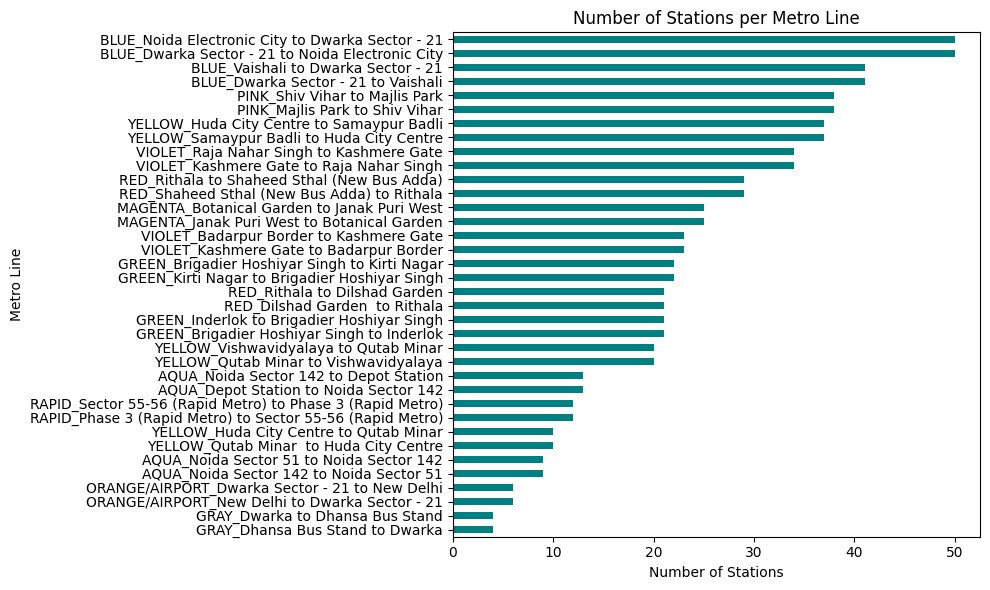

In [93]:
# Get unique stop_id-route_id mapping
trip_stop = stop_times[['trip_id', 'stop_id']].merge(trips[['trip_id', 'route_id']], on='trip_id').drop_duplicates()
trip_stop = trip_stop.merge(routes[['route_id', 'route_long_name']], on='route_id', how='left')
# Count unique stations per route
station_counts = trip_stop.groupby('route_long_name')['stop_id'].nunique().sort_values(ascending=False)
# Plot
import matplotlib.pyplot as plt
station_counts.plot(kind='barh', figsize=(10,6), color='teal')
plt.xlabel("Number of Stations")
plt.ylabel("Metro Line")
plt.title("Number of Stations per Metro Line")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [99]:
merged = stop_times[['trip_id', 'stop_id']].merge(trips[['trip_id', 'route_id']], on='trip_id').drop_duplicates()

# Count how many routes each station is part of
interchange_counts = merged.groupby('stop_id')['route_id'].nunique().reset_index()
interchange_counts.columns = ['stop_id', 'num_routes']

# Merge with stop names
interchange_counts = interchange_counts.merge(stops[['stop_id', 'stop_name']], on='stop_id', how='left')

# Interchange stations = those with 2 or more routes
interchanges = interchange_counts[interchange_counts['num_routes'] >= 2]

# Display
print("Interchange Stations:")
print(interchanges.sort_values(by='num_routes', ascending=False).head(10))

Interchange Stations:
     stop_id  num_routes            stop_name
7          8          12        Kashmere Gate
49        50           8          Rajiv Chowk
91        92           8          Mandi House
51        52           8  Central Secretariat
67        68           6          Sikanderpur
55        56           6     Dilli Haat - INA
58        59           6            Hauz Khas
61        62           6          Qutab Minar
126      127           6         Lajpat Nagar
107      108           6      Janak Puri West


In [95]:
# Find first and last stops in each trip
stop_times_sorted = stop_times.sort_values(by=['trip_id', 'stop_sequence'])
first_last_stops = stop_times_sorted.groupby('trip_id').agg(
    first_stop=('stop_id', 'first'),
    last_stop=('stop_id', 'last')
).reset_index()

# Count frequency of being a terminal
terminal_freq = pd.concat([
    first_last_stops['first_stop'].value_counts(),
    first_last_stops['last_stop'].value_counts()
], axis=1).sum(axis=1).reset_index()

terminal_freq.columns = ['stop_id', 'terminal_count']

# Add station names
terminal_freq = terminal_freq.merge(stops[['stop_id', 'stop_name']], on='stop_id', how='left')

# Sort and show
print("Likely Terminal Stations:")
print(terminal_freq.sort_values(by='terminal_count', ascending=False).head(10))

Likely Terminal Stations:
    stop_id  terminal_count                   stop_name
0        62             958                 Qutab Minar
1       121             957          Dwarka Sector - 21
3        71             730            Huda City Centre
2       508             672            Noida Sector 142
4         8             529               Kashmere Gate
5        44             485             Vishwavidyalaya
6       520             448               Depot Station
7       202             429    Brigadier Hoshiyar Singh
17       21             390                     Rithala
9       172             376  Sector 55-56 (Rapid Metro)


<Axes: ylabel='route_long_name'>

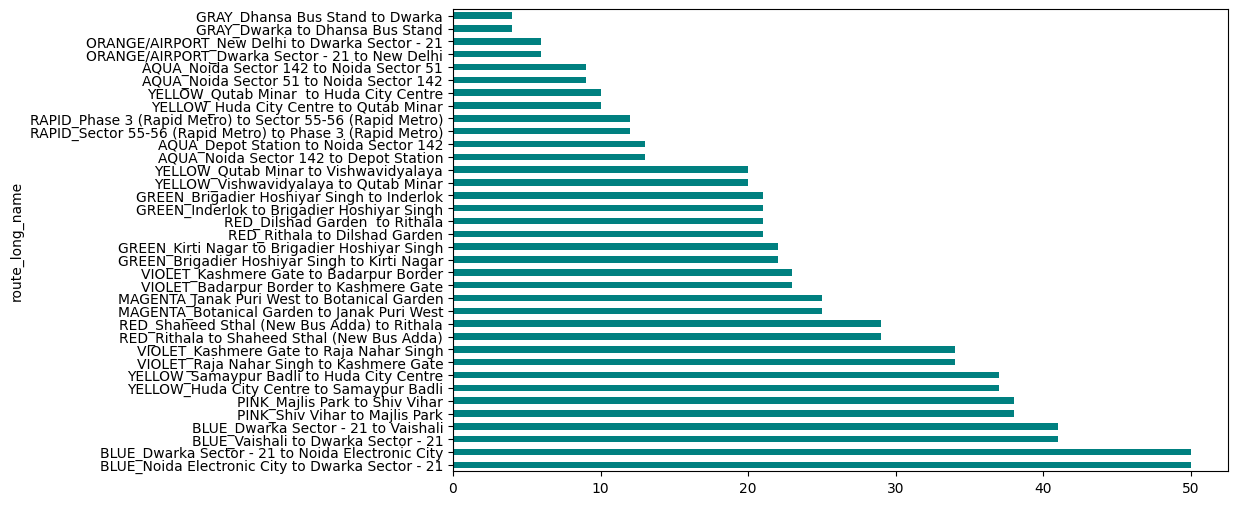

In [96]:
## 📊 Step 5: Stations per Metro Line
trip_stop = stop_times[['trip_id', 'stop_id']].merge(trips[['trip_id', 'route_id']], on='trip_id').drop_duplicates()
trip_stop = trip_stop.merge(routes[['route_id', 'route_long_name']], on='route_id', how='left')
station_counts = trip_stop.groupby('route_long_name')['stop_id'].nunique().sort_values(ascending=False)
station_counts.plot(kind='barh', figsize=(10,6), color='teal')


How did we optimise Delhi Metro using Data Science.

1. 📈 Identified Overcrowded Stations During Peak Hours
	•	Extracted time-wise train stop data from the datasets.
	•	Counted train arrivals at each station during peak.
	•	Insight: Stations like Kashmere Gate, Rajiv Chowk, and Mandi House have the highest load.
	•	Actionable Output: Recommend higher train frequency or longer trains during peak on affected lines.

2. 🔄 Detected Interchange Stations (Multi-Line Hubs)
	•	Calculated how many lines pass through each station.
	•	Found stations where 2 or more lines intersect.
	•	Insight: Kashmere Gate and Central Secretariat are heavily loaded interchange nodes.
	•	Actionable Output: Optimize crowd movement and buffer time in schedules at these interchanges.

3. 🔚 Analyzed Terminal Stations
	•	Found where trips most frequently start or end.
	•	Examples: Dwarka Sec 21, Huda City Centre, Qutub Minar.
	•	Insight: These are key turnaround points for scheduling.
	•	Actionable Output: Improve train planning.

4. 🚇 Line-Wise Station Count Analysis
	•	Measured number of stations served by each route.
	•	Identified dense corridors (e.g. Blue Line has 40+ stations).
	•	Insight: Longer lines likely suffer from schedule change, overcrowding.
	•	Actionable Output: Suggest splitting or segmenting operations (e.g. partial routes in off-peak).

5. 📍 Created Visual Maps for Metro Layout & Flow
	•	Used Folium to plot lines and stations with route-specific colors.
	•	Station Markers and coloured Routes added.
	•	Actionable Output: Easy identification of gaps, and high-traffic routes for planners.
